In [1]:
import pandas as pd
df = pd.read_excel("data/LCD_byRegionSex_2019.xlsx", sheet_name="DAVIDSON", skiprows=2, engine="openpyxl" )
# clean up rows with missing data
df = df.dropna(how="all")
#reset index
df = df.reset_index(drop=True)
print(df.shape)
print(df.head())

(20, 13)
                      Unnamed: 0 Unnamed: 1 Unnamed: 2  Unnamed: 3  \
0                          CAUSE      TOTAL        NaN         NaN   
1                            NaN       RANK     NUMBER        RATE   
2              DISEASES OF HEART          1       1155   166.39055   
3            MALIGNANT NEOPLASMS          2       1047  150.831953   
4  ACCIDENTS AND ADVERSE EFFECTS          3        581   83.699489   

          Unnamed: 4 Unnamed: 5 Unnamed: 6  Unnamed: 7         Unnamed: 8  \
0                NaN       MALE        NaN         NaN                NaN   
1  AGE ADJUSTED RATE       RANK     NUMBER        RATE  AGE ADJUSTED RATE   
2         172.678505          1        666  199.190676         240.148034   
3         151.183093          2        532  159.113272         179.823899   
4          83.375858          3        384  114.848678         118.261565   

  Unnamed: 9 Unnamed: 10 Unnamed: 11        Unnamed: 12  
0     FEMALE         NaN         NaN             

In [3]:
# Create descriptive column names
# The Excel has groups: TOTAL, MALE, FEMALE with metrics: RANK, NUMBER, RATE, AGE ADJUSTED RATE

# Get current column names
old_columns = df.columns.tolist()
print("Original columns:", old_columns)

# Define the prefixes and metrics
prefixes = ['Total', 'Male', 'Female']
metrics = ['Rank', 'Number', 'Rate', 'Age_Adjusted_Rate']

# Create new column names
new_columns = ['Cause']  # First column is the cause
for prefix in prefixes:
    for metric in metrics:
        new_columns.append(f"{prefix}_{metric}")

# Rename the columns
df.columns = new_columns
print("\nNew columns:", df.columns.tolist())
print(df.head())

Original columns: ['Cause', 'Total_Rank', 'Total_Number', 'Total_Rate', 'Total_Age_Adjusted_Rate', 'Male_Rank', 'Male_Number', 'Male_Rate', 'Male_Age_Adjusted_Rate', 'Female_Rank', 'Female_Number', 'Female_Rate', 'Female_Age_Adjusted_Rate']

New columns: ['Cause', 'Total_Rank', 'Total_Number', 'Total_Rate', 'Total_Age_Adjusted_Rate', 'Male_Rank', 'Male_Number', 'Male_Rate', 'Male_Age_Adjusted_Rate', 'Female_Rank', 'Female_Number', 'Female_Rate', 'Female_Age_Adjusted_Rate']
                           Cause Total_Rank Total_Number  Total_Rate  \
0                          CAUSE      TOTAL          NaN         NaN   
1                            NaN       RANK       NUMBER        RATE   
2              DISEASES OF HEART          1         1155   166.39055   
3            MALIGNANT NEOPLASMS          2         1047  150.831953   
4  ACCIDENTS AND ADVERSE EFFECTS          3          581   83.699489   

  Total_Age_Adjusted_Rate Male_Rank Male_Number   Male_Rate  \
0                     NaN 

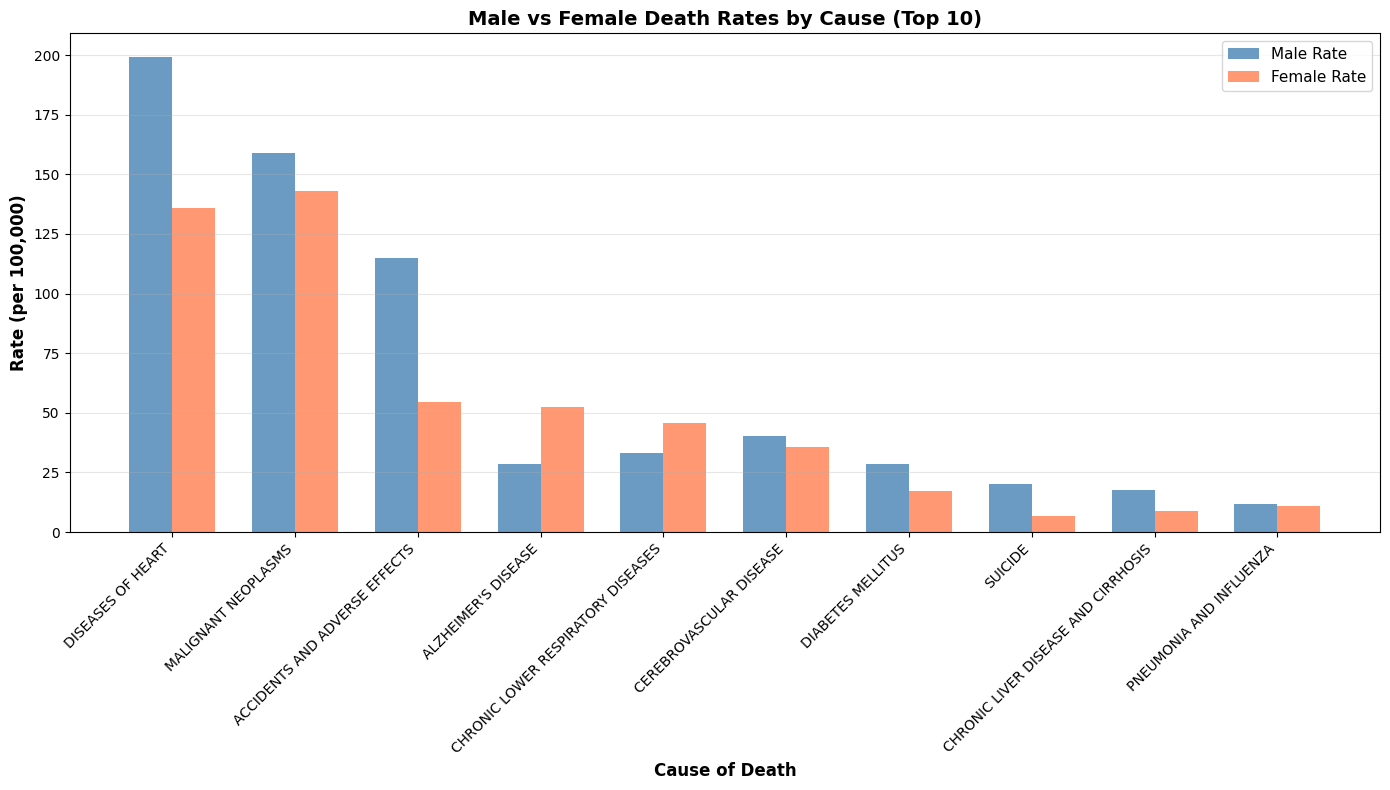

In [6]:
# create side by side bar chart comparing male vs female rate
import matplotlib.pyplot as plt
import seaborn as sns

# Filter out rows with non-numeric rates
chart_data = df.copy()
chart_data['Male_Rate'] = pd.to_numeric(chart_data['Male_Rate'], errors='coerce')
chart_data['Female_Rate'] = pd.to_numeric(chart_data['Female_Rate'], errors='coerce')
chart_data = chart_data.dropna(subset=['Male_Rate', 'Female_Rate'])

# Select top 10 causes for better visualization
top_10 = chart_data.head(10)

# Create figure and axis
fig, ax = plt.subplots(figsize=(14, 8))

# Set up the bar positions
x = range(len(top_10))
width = 0.35

# Create bars
bars1 = ax.bar([i - width/2 for i in x], top_10['Male_Rate'].values, width, label='Male Rate', alpha=0.8, color='steelblue')
bars2 = ax.bar([i + width/2 for i in x], top_10['Female_Rate'].values, width, label='Female Rate', alpha=0.8, color='coral')

# Customize the chart
ax.set_xlabel('Cause of Death', fontsize=12, fontweight='bold')
ax.set_ylabel('Rate (per 100,000)', fontsize=12, fontweight='bold')
ax.set_title('Male vs Female Death Rates by Cause (Top 10)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(top_10['Cause'].values, rotation=45, ha='right')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
# Create function to read and clean data for any region
def load_and_clean_region_data(region_name):
    """
    Load and clean death data for a specific region.
    
    Parameters:
    region_name (str): Sheet name in the Excel file
    
    Returns:
    pd.DataFrame: Cleaned dataframe with standardized column names
    """
    # Read the Excel file for the specified region
    df_region = pd.read_excel("data/LCD_byRegionSex_2019.xlsx", sheet_name=region_name, skiprows=2, engine="openpyxl")
    
    # Drop completely empty rows
    df_region = df_region.dropna(how="all")
    
    # Reset index
    df_region = df_region.reset_index(drop=True)
    
    # Rename columns with standardized names
    df_region.columns = new_columns
    
    # Convert Total_Rank to numeric and drop rows where Total_Rank is NaN
    # This handles regions with different row counts
    df_region['Total_Rank'] = pd.to_numeric(df_region['Total_Rank'], errors='coerce')
    df_region = df_region.dropna(subset=['Total_Rank'])
    
    # Reset index again after dropping rows
    df_region = df_region.reset_index(drop=True)
    
    return df_region

# Test the function with a different region
# First, let's see what sheet names are available
excel_file = pd.ExcelFile("data/LCD_byRegionSex_2019.xlsx")
print("Available regions (sheet names):")
print(excel_file.sheet_names)

Available regions (sheet names):
['DAVIDSON', 'EAST', 'HAMILTON', 'KNOX', 'MADISON', 'MID-CUMBERLAND', 'NORTHEAST', 'SHELBY', 'SOUTH CENTRAL', 'SOUTHEAST', 'SULLIVAN', 'UPPER CUMBERLAND', 'WEST']


In [9]:
# Test the function with a different region (e.g., SHELBY)
df_shelby = load_and_clean_region_data("SHELBY")
print("SHELBY region data shape:", df_shelby.shape)
print("\nFirst few rows:")
print(df_shelby.head())
print("\nData types:")
print(df_shelby.dtypes)

SHELBY region data shape: (12, 13)

First few rows:
                                Cause  Total_Rank Total_Number  Total_Rate  \
0                   DISEASES OF HEART         1.0         2061   219.91835   
1                 MALIGNANT NEOPLASMS         2.0         1694  180.757731   
2       ACCIDENTS AND ADVERSE EFFECTS         3.0          576   61.461897   
3             CEREBROVASCULAR DISEASE         4.0          491   52.391999   
4  CHRONIC LOWER RESPIRATORY DISEASES         5.0          319   34.038794   

  Total_Age_Adjusted_Rate Male_Rank Male_Number   Male_Rate  \
0              207.510714         1        1127  253.465186   
1              166.210962         2         885  199.038766   
2               61.072524         3         377   84.788265   
3               50.394223         4         225   50.603076   
4               31.905023         6         140   31.486359   

  Male_Age_Adjusted_Rate Female_Rank Female_Number Female_Rate  \
0             272.348195          

In [15]:
# Combine all regions into one DataFrame with region-prefixed column names
# Get all sheet names (regions)
all_regions = excel_file.sheet_names

# List to store dataframes for each region
dfs_list = []

# Loop through each region and load the data
for region in all_regions:
    df_region = load_and_clean_region_data(region)
    
    # Add region prefix to column names (except 'Cause')
    # Create a mapping for renamed columns
    rename_dict = {}
    for col in df_region.columns:
        if col != 'Cause':
            rename_dict[col] = f"{region}_{col}"
    
    # Rename the columns
    df_region = df_region.rename(columns=rename_dict)
    
    # Add a column for the region name
    df_region['Region'] = region
    
    # Append to list
    dfs_list.append(df_region)

# Combine all dataframes into one
df_all_regions = pd.concat(dfs_list, ignore_index=True)

print(f"Combined DataFrame shape: {df_all_regions.shape}")
print(f"\nNumber of regions: {len(all_regions)}")
print(f"Regions included: {all_regions}")
print(f"\nColumn names (first 10):")
print(df_all_regions.columns.tolist()[:10])
print(f"\nFirst few rows:")
print(df_all_regions.head())
print(f"\nData summary:")
print(df_all_regions.groupby('Region').size())

Combined DataFrame shape: (156, 158)

Number of regions: 13
Regions included: ['DAVIDSON', 'EAST', 'HAMILTON', 'KNOX', 'MADISON', 'MID-CUMBERLAND', 'NORTHEAST', 'SHELBY', 'SOUTH CENTRAL', 'SOUTHEAST', 'SULLIVAN', 'UPPER CUMBERLAND', 'WEST']

Column names (first 10):
['Cause', 'DAVIDSON_Total_Rank', 'DAVIDSON_Total_Number', 'DAVIDSON_Total_Rate', 'DAVIDSON_Total_Age_Adjusted_Rate', 'DAVIDSON_Male_Rank', 'DAVIDSON_Male_Number', 'DAVIDSON_Male_Rate', 'DAVIDSON_Male_Age_Adjusted_Rate', 'DAVIDSON_Female_Rank']

First few rows:
                                Cause  DAVIDSON_Total_Rank  \
0                   DISEASES OF HEART                  1.0   
1                 MALIGNANT NEOPLASMS                  2.0   
2       ACCIDENTS AND ADVERSE EFFECTS                  3.0   
3                 ALZHEIMER'S DISEASE                  4.0   
4  CHRONIC LOWER RESPIRATORY DISEASES                  5.0   

  DAVIDSON_Total_Number DAVIDSON_Total_Rate DAVIDSON_Total_Age_Adjusted_Rate  \
0                  

Top 3 causes by average male death rate:
1. DISEASES OF HEART: 311.10
2. MALIGNANT NEOPLASMS: 251.13
3. ACCIDENTS AND ADVERSE EFFECTS: 92.37


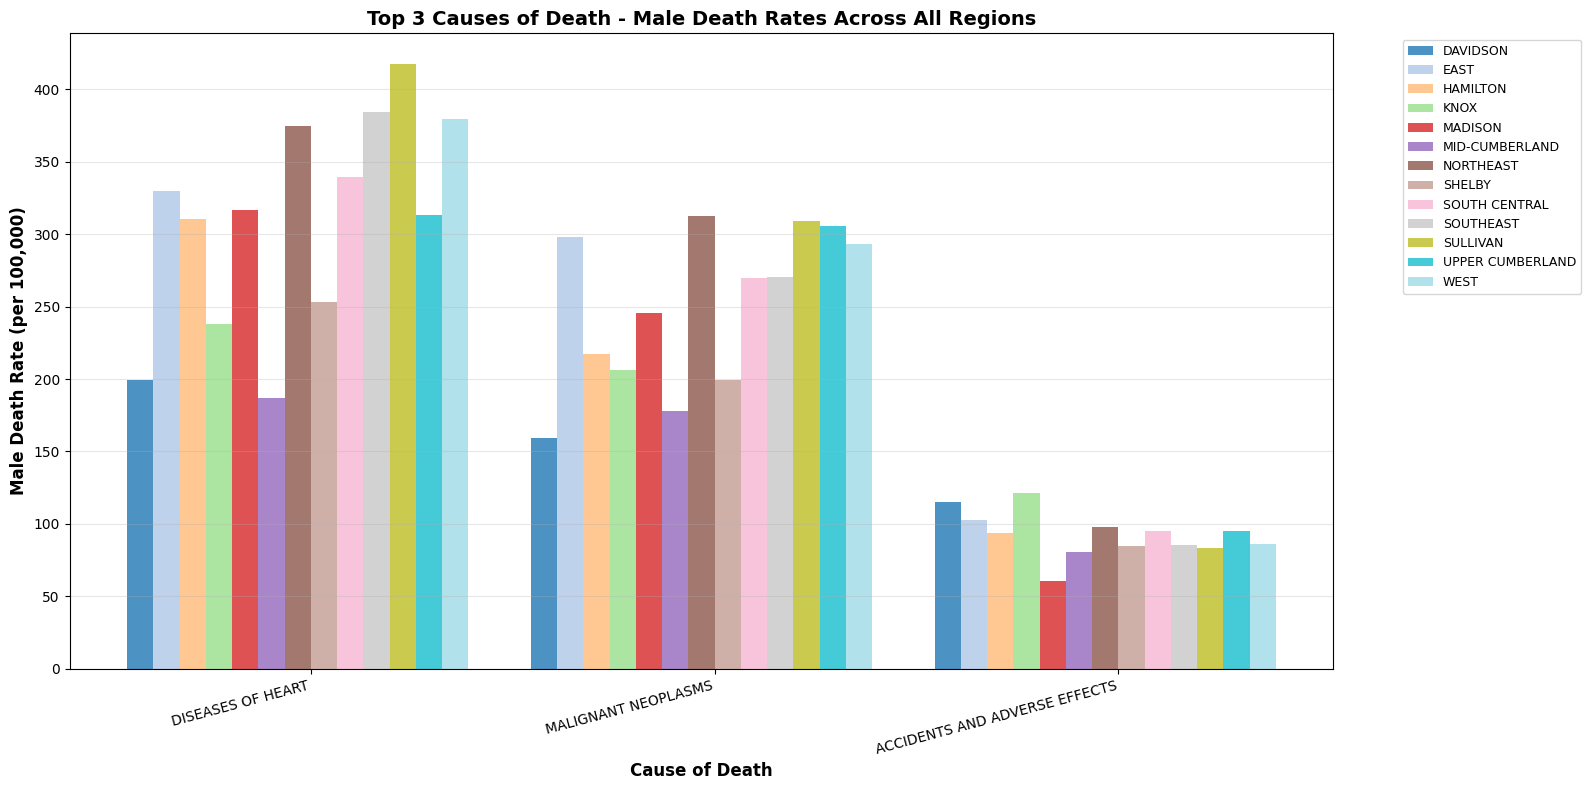

In [17]:
# Create bar chart comparing top 3 causes of death for male_rate across all regions
import matplotlib.pyplot as plt
import numpy as np

# Extract all male_rate columns
male_rate_cols = [col for col in df_all_regions.columns if 'Male_Rate' in col]

# Convert male_rate columns to numeric and create a copy
df_numeric = df_all_regions.copy()
for col in male_rate_cols:
    df_numeric[col] = pd.to_numeric(df_numeric[col], errors='coerce')

# Calculate average male rate for each cause to identify top 3
avg_male_rates = df_numeric.groupby('Cause')[male_rate_cols].mean().mean(axis=1).sort_values(ascending=False)
top_3_causes = avg_male_rates.head(3).index.tolist()

print(f"Top 3 causes by average male death rate:")
for i, cause in enumerate(top_3_causes, 1):
    print(f"{i}. {cause}: {avg_male_rates[cause]:.2f}")

# Filter data for top 3 causes
df_top3 = df_numeric[df_numeric['Cause'].isin(top_3_causes)].copy()

# Create a long-format dataframe for plotting
plot_data = []
for cause in top_3_causes:
    for region in all_regions:
        row_data = df_top3[(df_top3['Cause'] == cause) & (df_top3['Region'] == region)]
        if not row_data.empty:
            col_name = f"{region}_Male_Rate"
            rate = row_data[col_name].values[0]
            if pd.notna(rate):
                plot_data.append({'Cause': cause, 'Region': region, 'Male_Rate': float(rate)})

df_plot = pd.DataFrame(plot_data)

# Create grouped bar chart
fig, ax = plt.subplots(figsize=(16, 8))

# Get unique causes and regions
causes = df_plot['Cause'].unique()
regions = sorted(df_plot['Region'].unique())
n_regions = len(regions)

# Set bar positions
x_pos = np.arange(len(causes))
bar_width = 0.065
colors = plt.cm.tab20(np.linspace(0, 1, n_regions))

# Plot bars for each region
for i, region in enumerate(regions):
    region_data = df_plot[df_plot['Region'] == region]
    # Sort by cause to ensure proper alignment
    region_data = region_data.set_index('Cause').reindex(causes).reset_index()
    
    positions = x_pos + (i - n_regions/2) * bar_width
    ax.bar(positions, region_data['Male_Rate'], bar_width, label=region, color=colors[i], alpha=0.8)

# Customize chart
ax.set_xlabel('Cause of Death', fontsize=12, fontweight='bold')
ax.set_ylabel('Male Death Rate (per 100,000)', fontsize=12, fontweight='bold')
ax.set_title('Top 3 Causes of Death - Male Death Rates Across All Regions', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(causes, rotation=15, ha='right')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9, ncol=1)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()